# PVPlant 논문 구현하기

> Hybrid Deep Learning Models for Power Output Forecasting of Grid-Connected Solar PV Systems: A Monocrystalline and Polycrystalline PV Panel Analysis   
> - Owolabi et al. (2025)

In [1]:
import pandas as pd
import numpy as np
import folium
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data preparation 

1. Data collection 
    - Weather data and PV output -> Collection meter
    - 상대적으로 완전하고 정확한 측정이 존재하는 년도 선택
    - 두 가지 종류의 solar PV technologies 선택
        - 285Wp monocrystalline silicon (mono-si) PV manufactured by Risen Energy
        - 265Wp polycrystalline silicon (poly-si) solar cell manufactured by Yingli
2. Data pre-proccessing and splitting
    - Raw data -> Data cleaning -> Data analysis
    - Data cleaning, resampling, splitting, denoising, normaization 
    
    - absolute correlation coefficient >= 0.35인 입력 변수만 모델 학습에 채택
        - nwp_globalirrad, nwp_directirrad, nwp_temperature,nwp_humidity, lmd_totalirrad, lmd_diffuseirrad, lmd_temperature
    - 정규화: MinMAx Scaling (0-1) 
    - splitting
        - training set: 70%
        - testing set: 30%
            - validation set: 15%
            - fianl test: 15%
    - 표준화: z-score standardization 


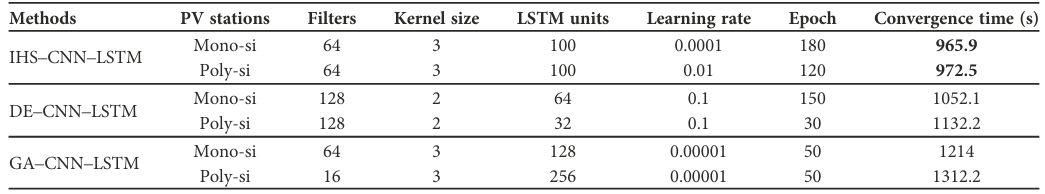

Mono-si, Poly-si 데이터 추출

In [2]:
metadata = pd.read_csv("PVODdatasets_v1.0/metadata.csv")

# 조건 만족하는 행만 추출 (추후)
# mono = metadata[(metadata["Panel_Size"] == 1.6368) & (metadata["Array_Tilt"] == "South 29°")]
# poly = metadata[(metadata["Panel_Size"] == 1.6335) & (metadata["Array_Tilt"] == "South 33°")]

지도 시각화
- 두 station 모두 동일한 Hebei 지역에 위치

In [23]:
# station 지도 시각화

# Station02, Station03만 필터링
stations = metadata[metadata["Station_ID"].isin(["station02", "station08"])]

# 지도 초기화 (중심: 필터링된 좌표 평균)
m = folium.Map(location=[stations["Latitude"].mean(), stations["Longitude"].mean()], zoom_start=5)

# 마커 추가
for _, row in stations.iterrows():
    folium.Marker(
        location=[row["Latitude"], row["Longitude"]],
        popup=f"Station: {row['Station_ID']}"
    ).add_to(m)
m.save("station_map.html")
m

station별 데이터

1. 열 설명
    - date_time: timstamp   
**NWP (Numerical Weather Prediction, 수치예보 모델 출력 값)**   
    - nwp_globalirrad: Global Irradiance (태양이 지표면에 도달하는 총 일사량 (W/m2))
    - nwp_directirrad: Direct Irradiance (태양에서 직접 도달하는 일사 성분 (W/m2))
    - nwp_temperature: 기온, NWP에서 예측된 값
    - nwp_humidity: 상대습도, NWP에서 예측된 값
    - nwp_windspeed: 풍속, NWP 예보 값
    - nwp_winddirection: 풍향, NWP 예보 값
    - nwp_pressure: 기압, NWP 예보 값   
**LMD (Local Meteorological Data, 현장 기상 관측 데이터)**   
    - lmd_totalirrad: 총 일사량(Global Irradiance), 현장 측정 값   
    - lmd_diffuseirrad: 산란일사량(Diffuse Irradiance), 구름/대기 산란을 통해 도달하는 성분
    - lmd_temperature: 기온, 현장 기상 센서 측정 값
    - lmd_pressure: 기압, 현장 기상 센서 측정 값
    - lmd_winddirection: 풍향, 현장 측정 값
    - lmd_windspeed: 풍속, 현장 측정 값   
**발전소 성능**   
    - power: 실제 발전소의 전력 출력   

In [4]:
mono_station = pd.read_csv("PVODdatasets_v1.0/station02.csv")
poly_station = pd.read_csv("PVODdatasets_v1.0/station08.csv")

mono_station["Station_ID"] = "station02"
poly_station["Station_ID"] = "station08"
stations = pd.concat([mono_station, poly_station], ignore_index=True)
# Statio_ID를 맨 처음으로 이동
stations = stations[["Station_ID"] + [col for col in stations.columns if col != "Station_ID"]]

mono_station.drop(columns=["Station_ID"], inplace=True)
poly_station.drop(columns=["Station_ID"], inplace=True)

In [ ]:
# data_time 2018.07 - 2018.11까지만 추출
stations = stations[(stations["date_time"] >= "2018-07-23") & (stations["date_time"] < "2019-06-10")]

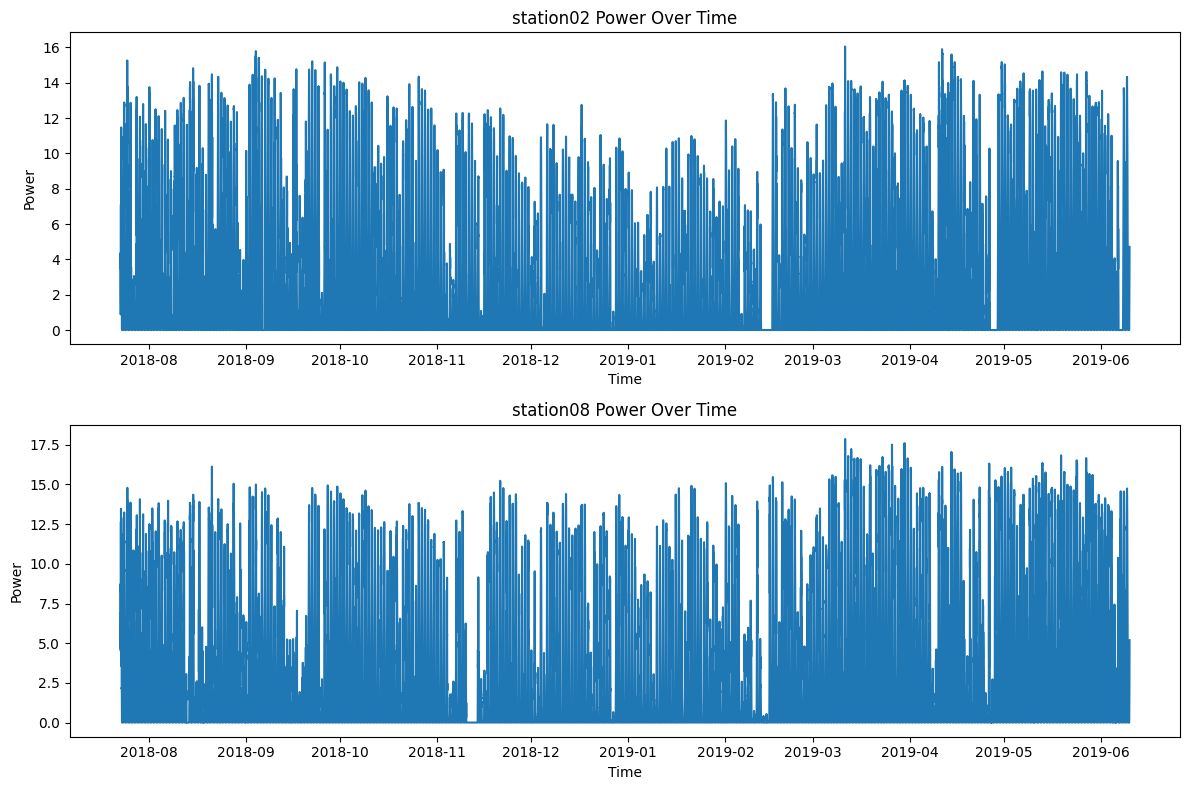

In [6]:
# 각 발전소별 power 시계열 시각화

# date_time 컬럼이 문자열이면 datetime 변환
stations['date_time'] = pd.to_datetime(stations['date_time'])

# 발전소 ID 목록
station_ids = stations['Station_ID'].unique()

plt.figure(figsize=(12, 8))

for i, station_id in enumerate(station_ids, 1):
    subset = stations[stations['Station_ID'] == station_id]
    
    plt.subplot(len(station_ids), 1, i)
    plt.plot(subset['date_time'], subset['power'])
    plt.title(f'{station_id} Power Over Time')
    plt.xlabel('Time')
    plt.ylabel('Power')

plt.tight_layout()
plt.show()

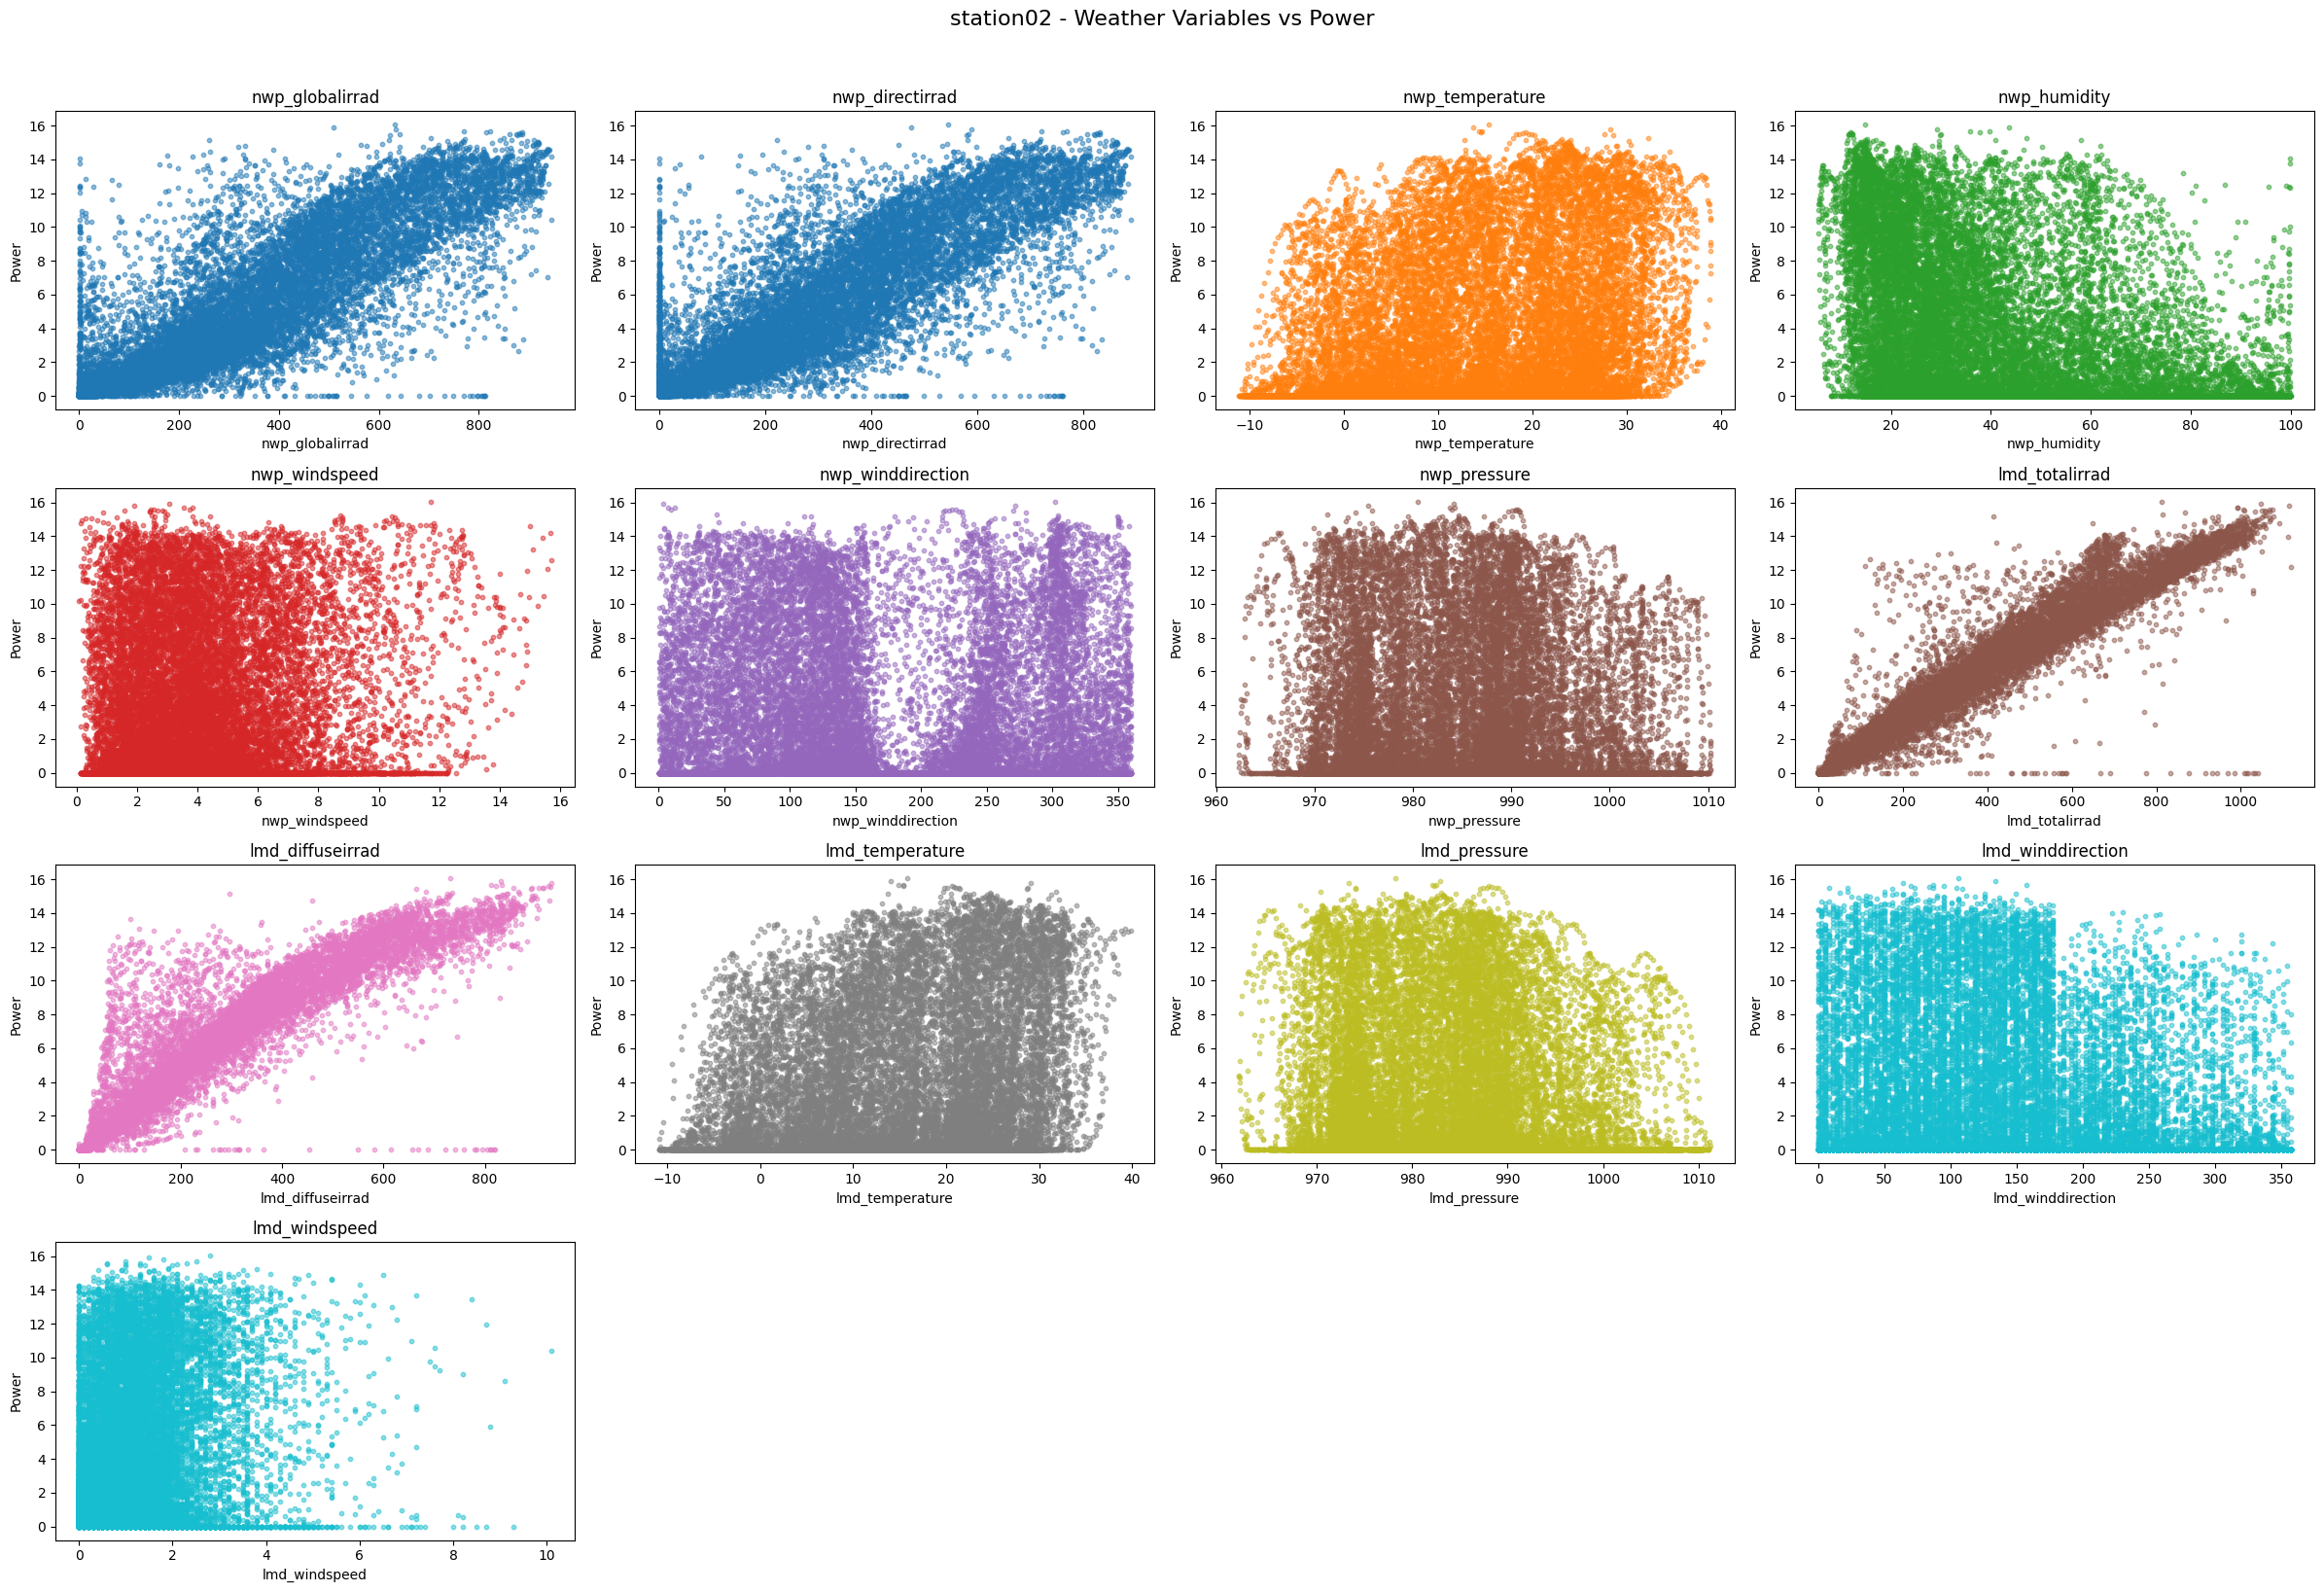

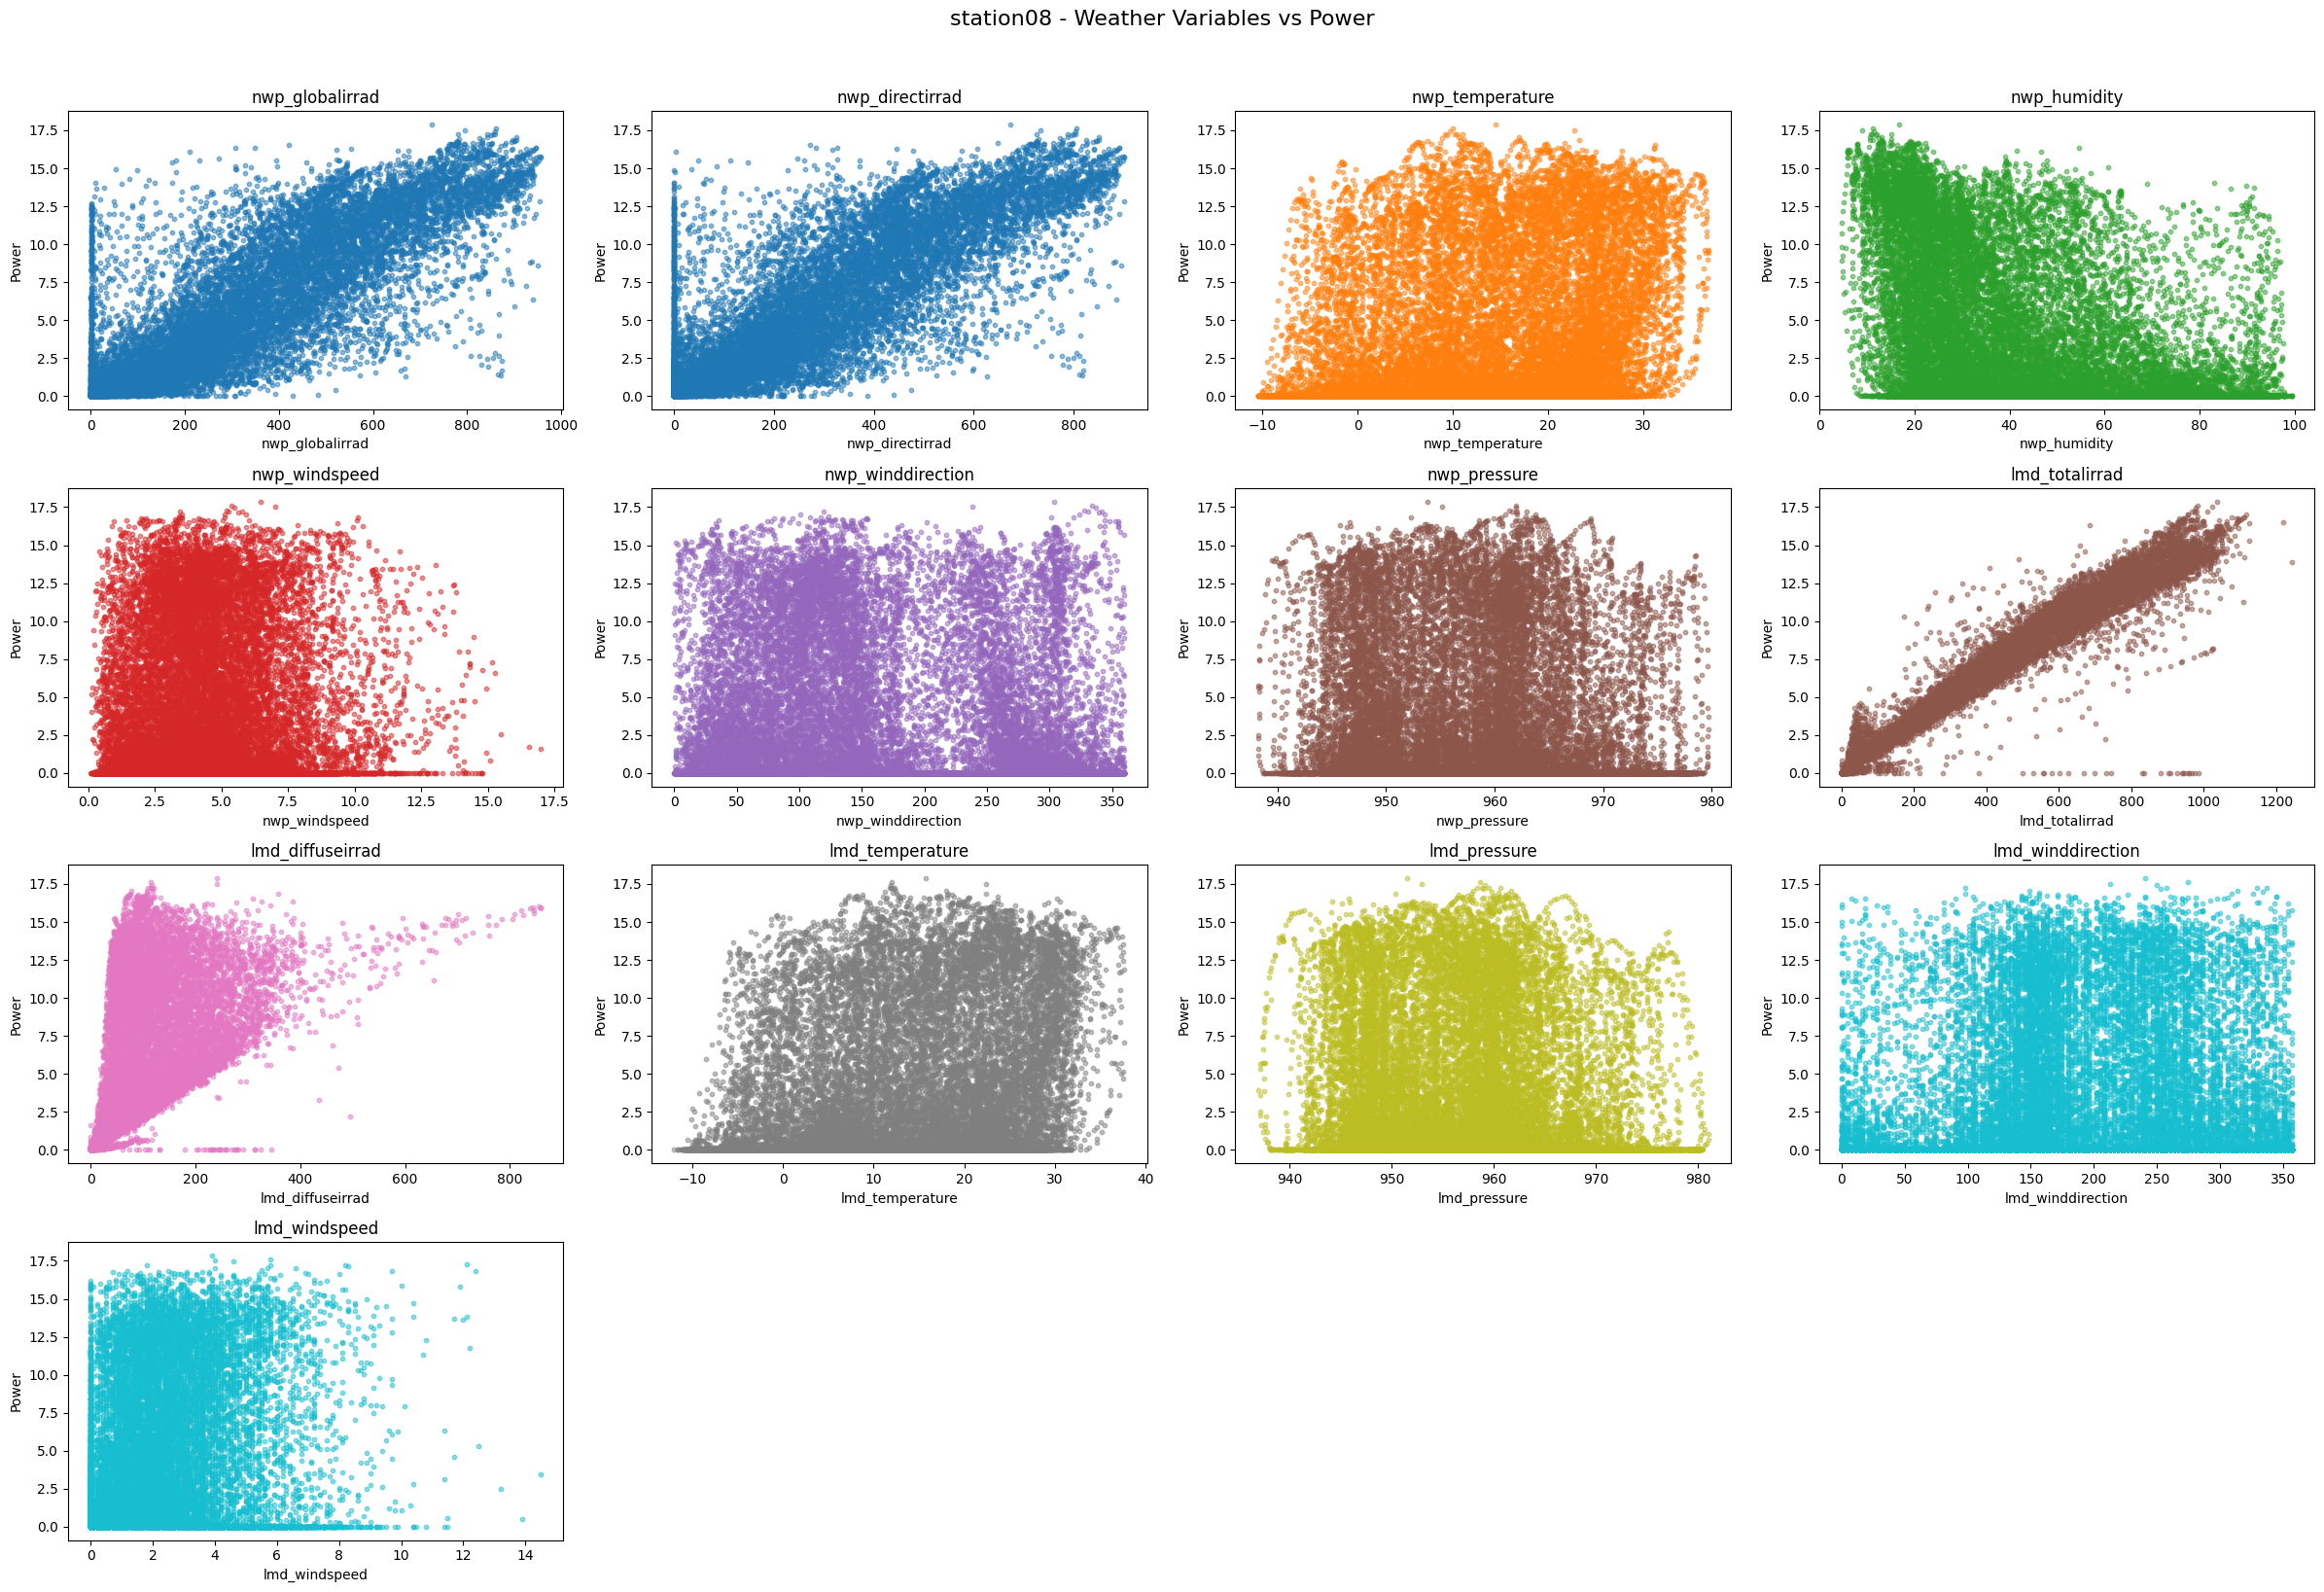

In [7]:
import matplotlib.cm as cm

# 기상 변수 목록 (Station_ID, date_time, power 제외)
weather_cols = [col for col in stations.columns if col not in ['Station_ID', 'date_time', 'power']]
colors = cm.tab10(np.linspace(0, 1, len(weather_cols))) 

for station_id in station_ids:
    subset = stations[stations['Station_ID'] == station_id]
    
    ncols = 4
    nrows = math.ceil(len(weather_cols) / ncols)
    
    plt.figure(figsize=(6*ncols, 4*nrows))
    plt.suptitle(f"{station_id} - Weather Variables vs Power", fontsize=16, y=1.02)
    
    for j, col in enumerate(weather_cols):
        ax = plt.subplot(nrows, ncols, j+1)
        ax.scatter(subset[col], subset['power'], alpha=0.5, s=10, color=colors[j])
        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel("Power")
    
    plt.tight_layout()
    plt.show()

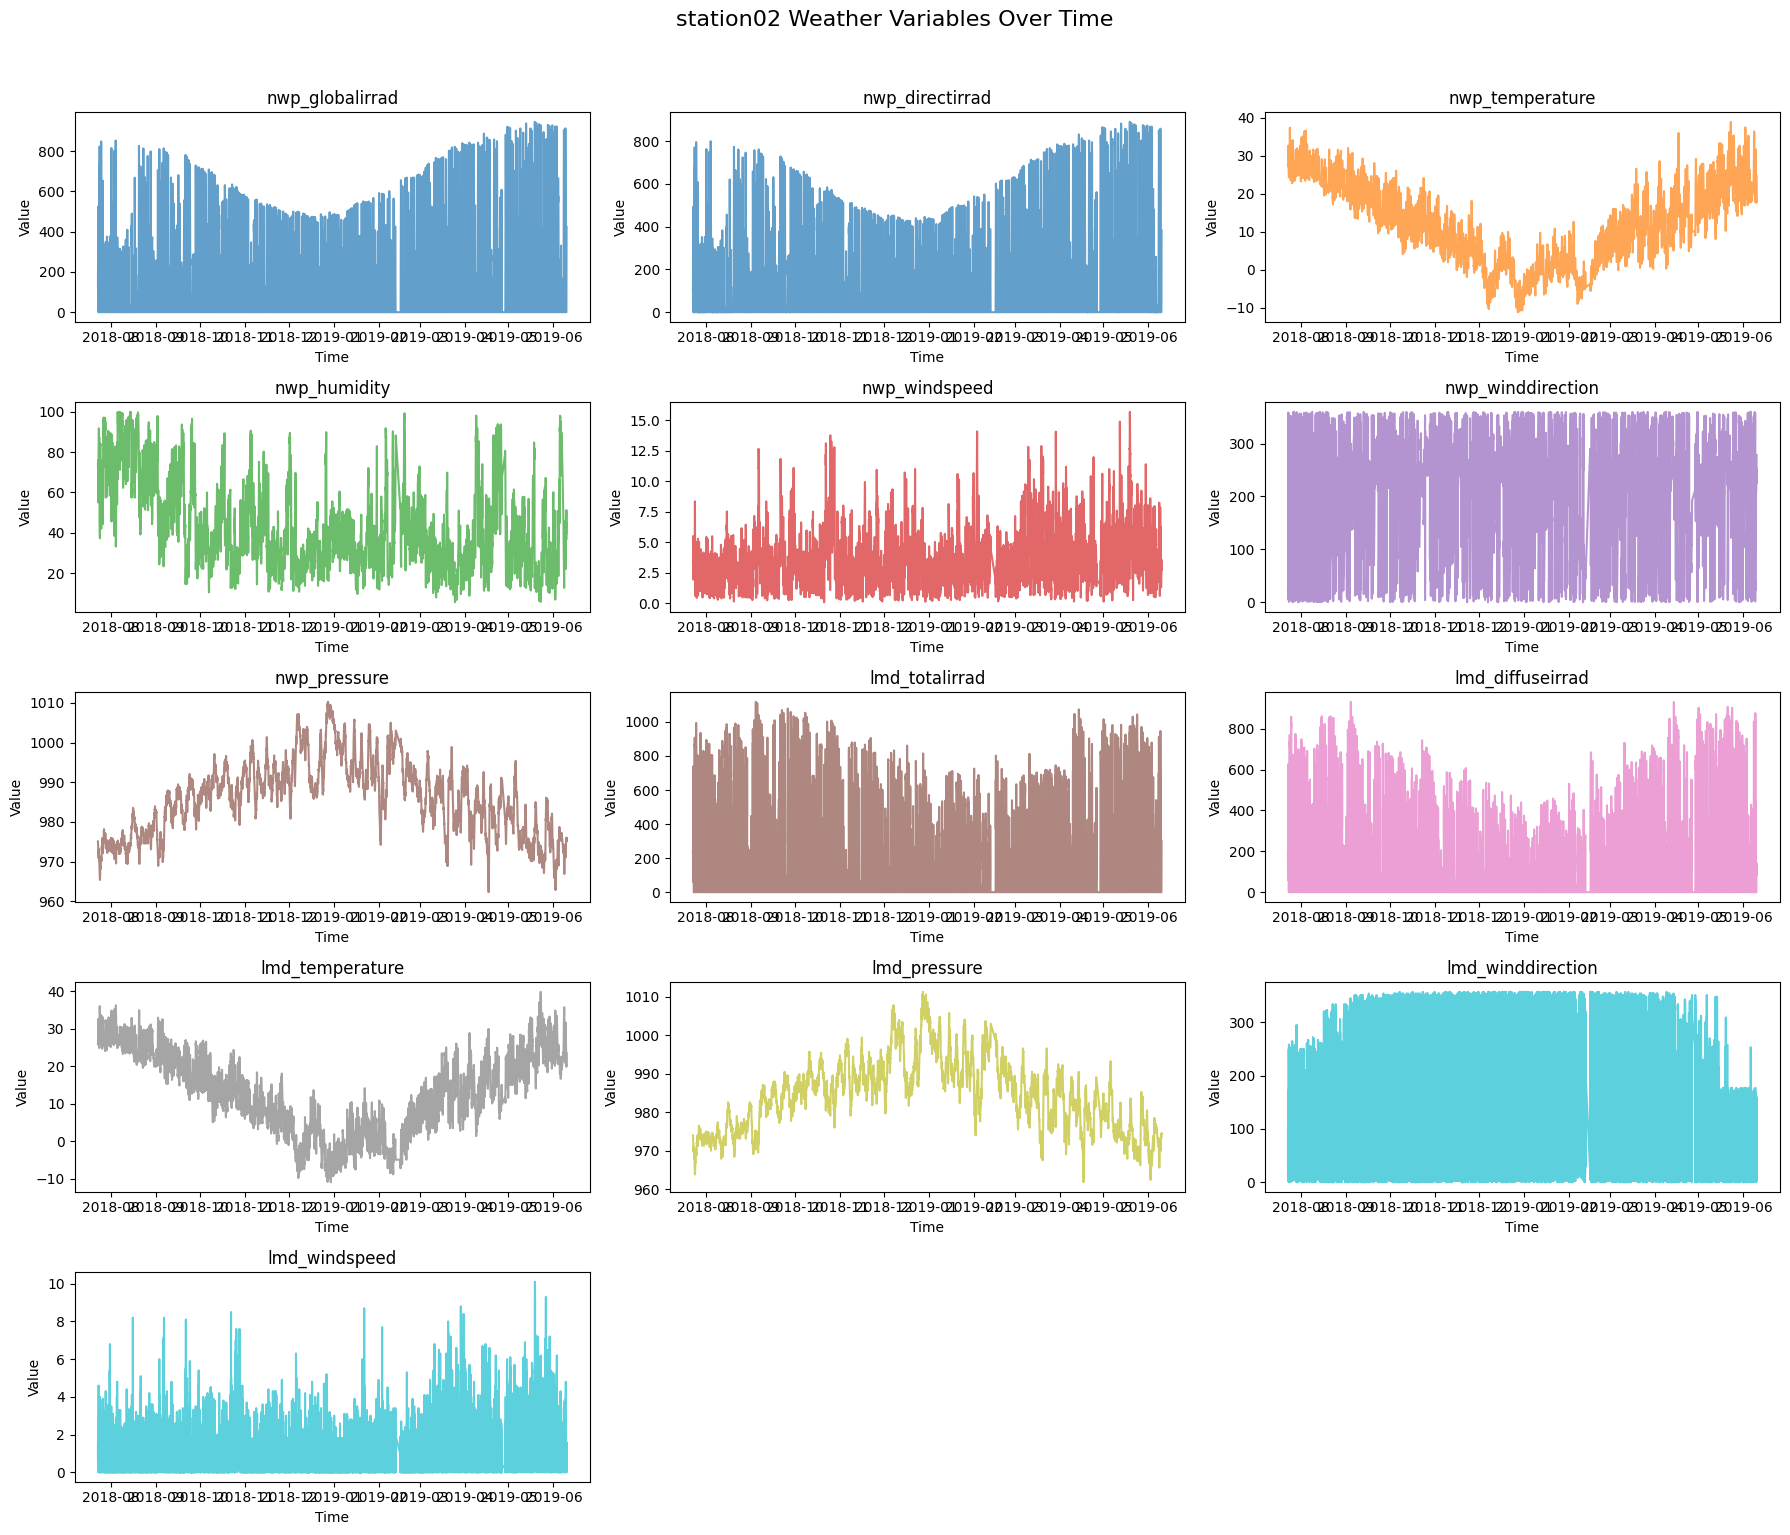

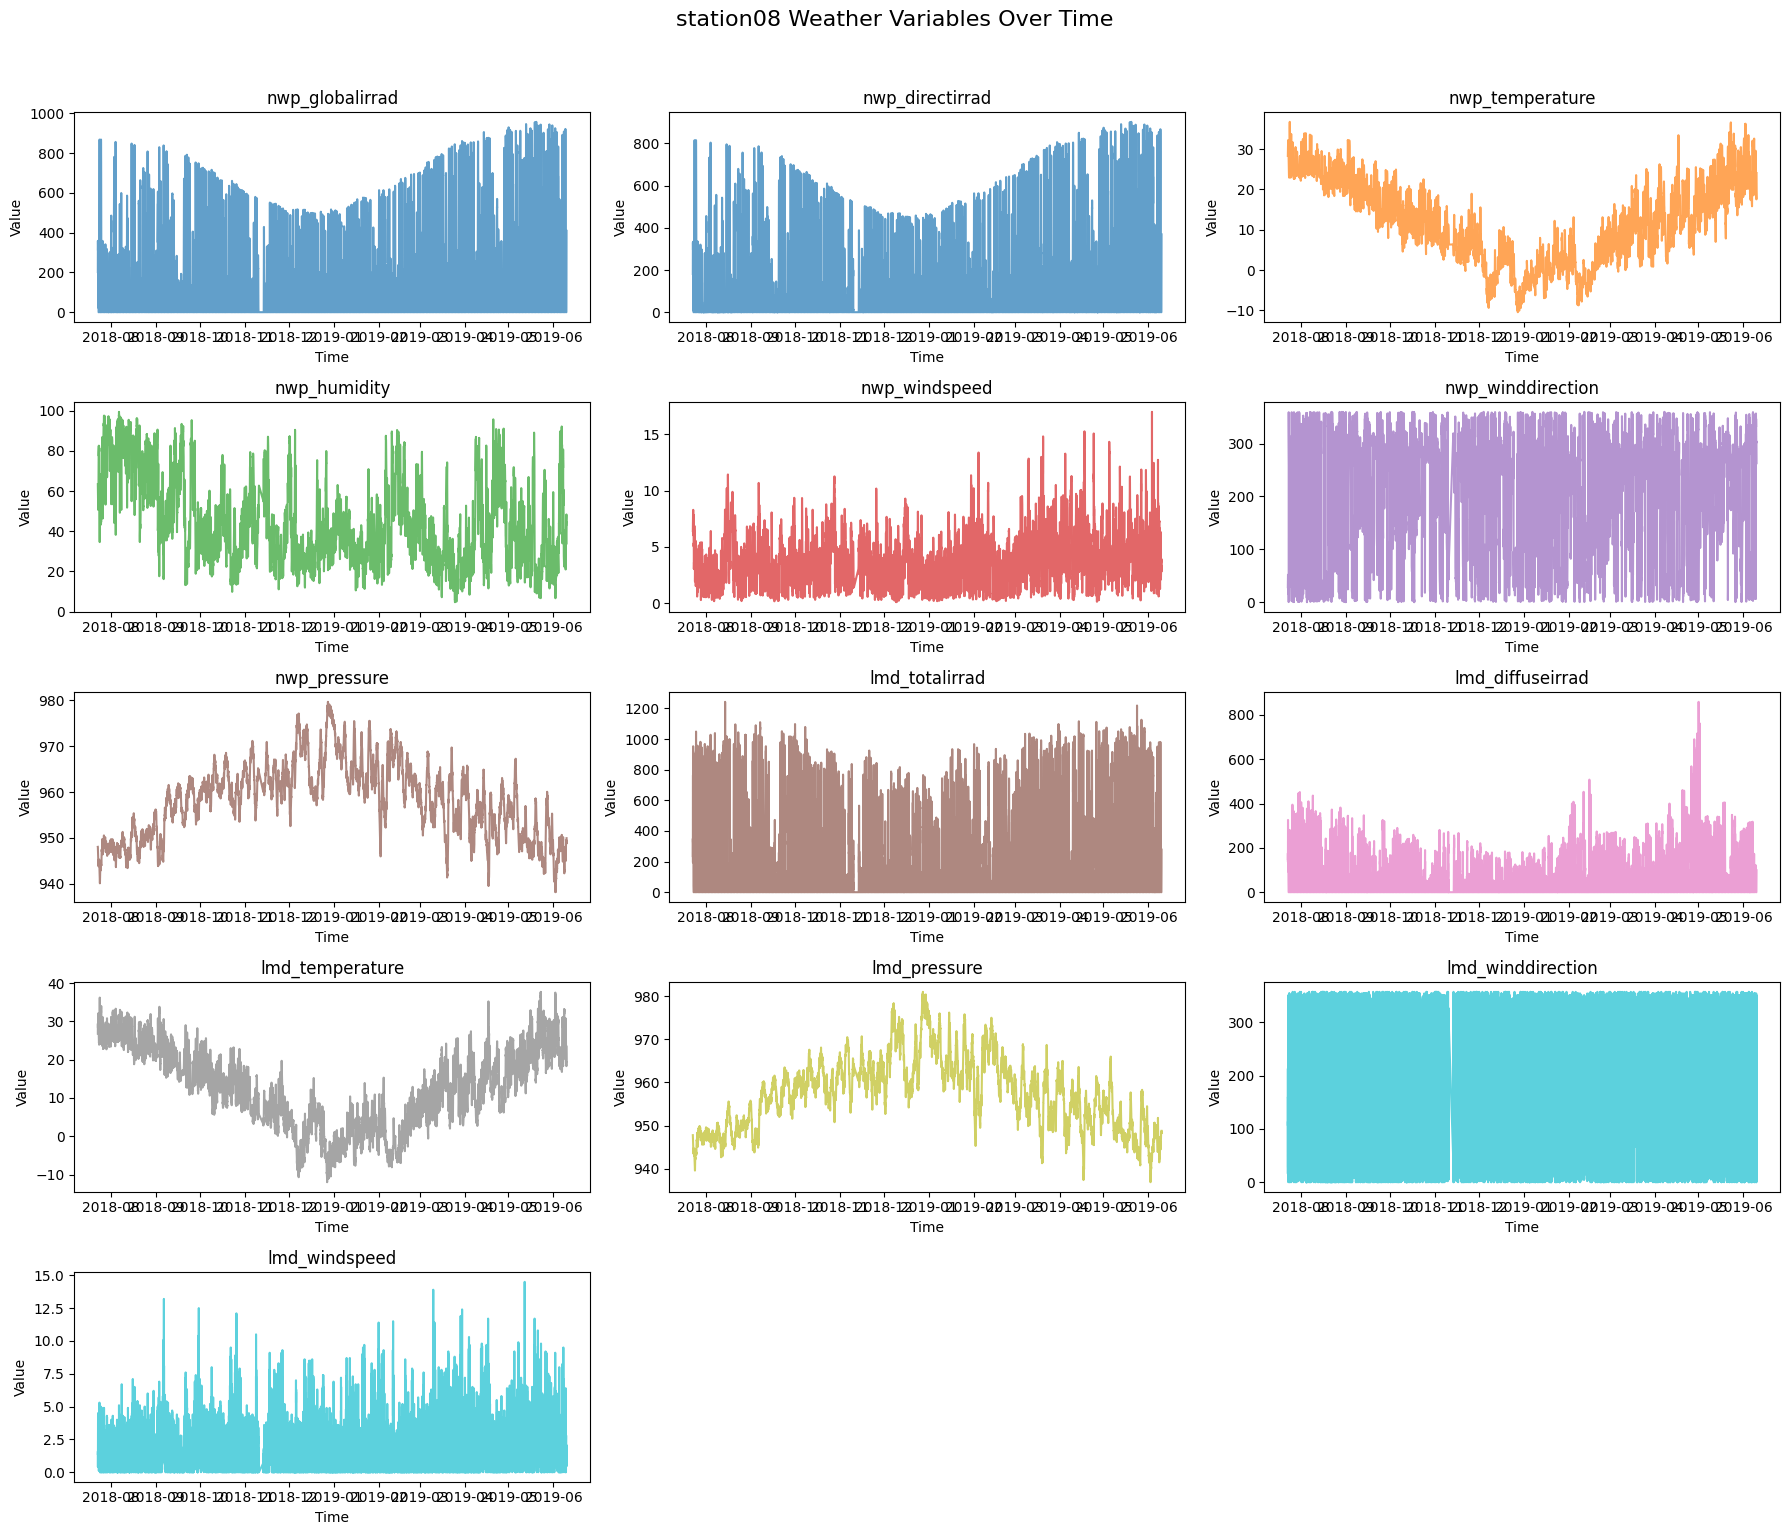

In [8]:
import math

for station_id in station_ids:
    subset = stations[stations['Station_ID'] == station_id]
    
    ncols = 3
    nrows = math.ceil(len(weather_cols) / ncols)
    
    plt.figure(figsize=(6*ncols, 3*nrows))
    plt.suptitle(f"{station_id} Weather Variables Over Time", fontsize=16, y=1.02)
    
    for i, col in enumerate(weather_cols, 1):
        ax = plt.subplot(nrows, ncols, i)
        ax.plot(subset['date_time'], subset[col], color=colors[i-1], alpha=0.7)
        ax.set_title(col)
        ax.set_xlabel("Time")
        ax.set_ylabel("Value")
    
    plt.tight_layout()
    plt.show()

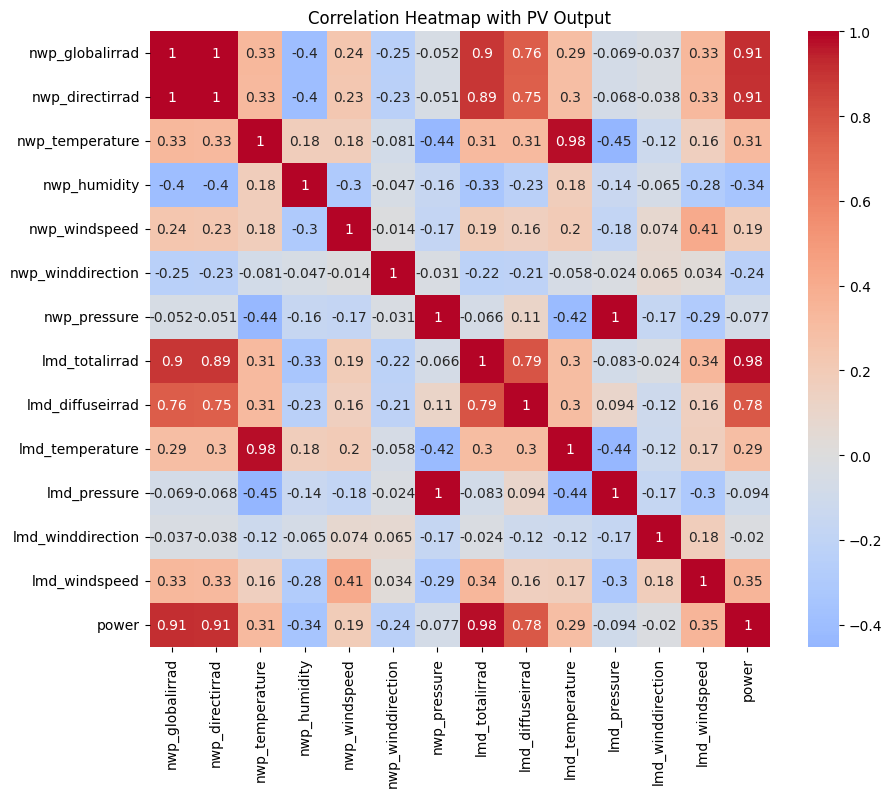

In [9]:
# 산점도 

# numeric 컬럼만 선택
numeric_cols = stations.select_dtypes(include=['float64','int64']).columns
corr = stations[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap with PV Output")
plt.show()


In [10]:
# 상관관계가 0.35 이상인 기상 변수들만 남기고 drop
stations = stations.drop(columns=['nwp_windspeed', 'nwp_winddirection', 'nwp_pressure', 'nwp_pressure', 'lmd_winddirection', 'lmd_windspeed', 'lmd_pressure'])

In [11]:
# import pandas as pd

# # Station02만 선택
# station02 = stations[stations["Station_ID"] == "station02"].copy()
# station02["date_time"] = pd.to_datetime(station02["date_time"], errors="coerce")

# # 인덱스 설정
# station02 = station02.set_index("date_time").sort_index()

# # 15분 단위로 재샘플링 (NaN 유지)
# station02_resampled = station02.resample("15T").asfreq()
# # station02_resampled = station02_resampled.interpolate(method="linear")
# # date_time을 다시 컬럼으로 복구
# station02_resampled = station02_resampled.reset_index()

# # Station_ID 컬럼이 사라졌다면 다시 넣어줌
# station02_resampled["Station_ID"] = "station02"

# # 기존 stations에서 Station02 제거 후 새 데이터 붙이기
# stations = pd.concat(
#     [
#         stations[stations["Station_ID"] != "station02"],
#         station02_resampled
#     ],
#     ignore_index=True
# ).sort_values(["Station_ID", "date_time"]).reset_index(drop=True)

# print("원래 Station02 크기:", station02.shape)
# print("재샘플링 후 Station02 크기:", station02_resampled.shape)
# print("최종 stations 크기:", stations.shape)


In [12]:
# import pandas as pd

# # Station08만 선택
# station08 = stations[stations["Station_ID"] == "station08"].copy()
# station08["date_time"] = pd.to_datetime(station08["date_time"], errors="coerce")

# # 인덱스 설정
# station08 = station08.set_index("date_time").sort_index()

# # 15분 단위로 재샘플링 (NaN 유지)
# station08_resampled = station08.resample("15T").asfreq()
# # station08_resampled = station08_resampled.interpolate(method="linear")
# # date_time을 다시 컬럼으로 복구
# station08_resampled = station08_resampled.reset_index()

# # Station_ID 컬럼이 사라졌다면 다시 넣어줌
# station08_resampled["Station_ID"] = "station08"

# # 기존 stations에서 Station08 제거 후 새 데이터 붙이기
# stations = pd.concat(
#     [
#         stations[stations["Station_ID"] != "station08"],
#         station08_resampled
#     ],
#     ignore_index=True
# ).sort_values(["Station_ID", "date_time"]).reset_index(drop=True)

# print("원래 Station08 크기:", station08.shape)
# print("재샘플링 후 Station08 크기:", station08_resampled.shape)
# print("최종 stations 크기:", stations.shape)


In [13]:
# 각 발전소별 시계열 데이터 범위 확인
for station_id, group in stations.groupby("Station_ID"):
    min_date = pd.to_datetime(group['date_time']).min()
    max_date = pd.to_datetime(group['date_time']).max()
    print(f"Station {station_id}: {min_date} to {max_date}, Total records: {len(group)}")


Station station02: 2018-07-23 00:00:00 to 2019-06-09 23:45:00, Total records: 30336
Station station08: 2018-07-23 00:00:00 to 2019-06-09 23:45:00, Total records: 30624


In [14]:
# station별 그룹화 후 NaN 개수 집계
nan_summary = stations.groupby("Station_ID").apply(lambda x: x.isna().sum())
nan_summary

C:\Users\ryudo\AppData\Local\Temp\ipykernel_22720\3167129451.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nan_summary = stations.groupby("Station_ID").apply(lambda x: x.isna().sum())


,Station_ID,date_time,nwp_globalirrad,nwp_directirrad,nwp_temperature,nwp_humidity,lmd_totalirrad,lmd_diffuseirrad,lmd_temperature,power
Station_ID,,,,,,,,,,
station02,0,0,0,0,0,0,0,0,0,0
station08,0,0,0,0,0,0,0,0,0,0


split

In [15]:
def get_train_val_test_split(station_data, station_col, train_ratio=0.7, val_ratio=0.15):
    # station_col 기준으로 그룹화
    grouped = station_data.groupby(station_col)
    
    train_data = pd.DataFrame()
    val_data = pd.DataFrame()
    test_data = pd.DataFrame()

    for _, group in grouped:
        total_len = len(group)
        train_end = int(total_len * train_ratio)
        val_end = int(total_len * (train_ratio + val_ratio))

        train_data = pd.concat([train_data, group.iloc[:train_end]])
        val_data = pd.concat([val_data, group.iloc[train_end:val_end]])
        test_data = pd.concat([test_data, group.iloc[val_end:]])

    return train_data, val_data, test_data

In [16]:
train, valid, test = get_train_val_test_split(stations, 'Station_ID')

In [25]:
# 각 발전소별 시계열 데이터 범위 확인
def get_date_range(df, station_col):
    date_ranges = {}
    for station_id, group in df.groupby(station_col):
        min_date = pd.to_datetime(group['date_time']).min()
        max_date = pd.to_datetime(group['date_time']).max()
        date_ranges[station_id] = (min_date, max_date)
    return date_ranges

print("Train Date Ranges:\n", get_date_range(train, "Station_ID"))
print("Validation Date Ranges:\n", get_date_range(valid, "Station_ID"))
print("Test Date Ranges:\n", get_date_range(test, "Station_ID"))

Train Date Ranges:
 {'station02': (Timestamp('2018-07-23 00:00:00'), Timestamp('2019-03-04 04:30:00')), 'station08': (Timestamp('2018-07-23 00:00:00'), Timestamp('2019-03-06 06:45:00'))}
Validation Date Ranges:
 {'station02': (Timestamp('2019-03-04 04:45:00'), Timestamp('2019-04-20 14:00:00')), 'station08': (Timestamp('2019-03-06 07:00:00'), Timestamp('2019-04-23 03:15:00'))}
Test Date Ranges:
 {'station02': (Timestamp('2019-04-20 14:15:00'), Timestamp('2019-06-09 23:45:00')), 'station08': (Timestamp('2019-04-23 03:30:00'), Timestamp('2019-06-09 23:45:00'))}


Data cleaning

In [20]:
# 이상치 NaN값 처리 

# NaN값 처리 


In [21]:
train

,Station_ID,date_time,nwp_globalirrad,nwp_directirrad,nwp_temperature,nwp_humidity,lmd_totalirrad,lmd_diffuseirrad,lmd_temperature,power
32,station02,2018-07-23 00:00:00,121.76,101.62,27.39,73.27,234,165,25.900000,3.54018
33,station02,2018-07-23 00:15:00,117.98,92.95,27.37,73.74,252,204,26.100000,4.35666
34,station02,2018-07-23 00:30:00,151.82,127.30,27.52,73.76,126,111,26.400000,2.17497
35,station02,2018-07-23 00:45:00,206.97,187.57,27.88,72.69,105,95,26.400000,2.14830
36,station02,2018-07-23 01:00:00,212.68,191.95,27.98,72.20,119,107,26.700001,2.23062
...,...,...,...,...,...,...,...,...,...,...
54007,station08,2019-03-06 05:45:00,711.33,659.92,9.08,21.25,873,143,11.600000,14.36440
54008,station08,2019-03-06 06:00:00,696.14,645.13,9.08,21.50,852,138,11.800000,14.13960
54009,station08,2019-03-06 06:15:00,669.05,618.76,9.07,21.83,823,133,11.600000,13.58081
54010,station08,2019-03-06 06:30:00,648.20,598.50,9.06,22.21,794,133,12.000000,13.02237


MinMax Scaling & z-score standardization

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# z-score standardization
Standardscaler = StandardScaler()
MinMaxscaler = MinMaxScaler()

# Min-Max scaling
# train_data
def train_scaler_fit_transform(df, scaler):
    df = df.copy()
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
    return df, scaler

# valid/test_data
def valid_test_scaler_transform(df, scaler):
    df = df.copy()
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    df[numeric_cols] = scaler.transform(df[numeric_cols])
    return df

train, minmax_scaler = train_scaler_fit_transform(train, MinMaxscaler)
valid = valid_test_scaler_transform(valid, minmax_scaler)
test = valid_test_scaler_transform(test,  minmax_scaler)

# z-score standardization
train_scaled, standard_scaler = train_scaler_fit_transform(train, Standardscaler)
valid_scaled = valid_test_scaler_transform(valid, standard_scaler)
test_scaled  = valid_test_scaler_transform(test,  standard_scaler)

## Model training and deployment

1. IHS Algorithm
    - Harmony Initialization 
    - Fitness Evaluation and Harmony Selection 
    - Termination 
2. DE (Differencial Evolution) and GA
    - Initialization 
    - Selection 
    - Mutation 
    - Crossover and Evaluation 
    - Termination 
3. LSTM
4. CNN
5. Ensemble Architecture of CNN and LSTM    

### IHS Algorithm

우선 생략

### CNN + LSTM

Mono-si   
- Filters = 64
- Kernal size = 3 
- Lstm units = 100
- Learning rate = 0.001
- Epoch = 180
- Convergence time(s) = 965.9

Poly-si    
- Filters = 64
- Kernal size = 3 
- Lstm units = 100
- Learning rate = 0.01
- Epoch = 120
- Convergence time(s) = 972.5

CNN

In [27]:
from models.PVPlant_CNN import PVPlantCNN

LSTM

In [ ]:
from models.PVPlant_LSTM import PVPlantLSTM
LSTM = PVPlantLSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    output_size=output_size, # 1
    num_layers=num_ls_layers,
    bidirectional=False,
    num_stations=num_stations,
    station_emb_dim=station_emb_dim,
    meta_dim=meta_dim,
    dropout=dropout
).to(device)
LSTM

In [ ]:
# (x, y, s, meta) 튜플로 묶어서 DataLoader에 전달
train_ds = SeqDataset(torch_train_x, torch_train_y, torch_train_s, torch_train_meta if meta_dim>0 else None)
valid_ds = SeqDataset(torch_valid_x, torch_valid_y, torch_valid_s, torch_valid_meta if meta_dim>0 else None)
test_ds  = SeqDataset(torch_test_x,  torch_test_y,  torch_test_s,  torch_test_meta  if meta_dim>0 else None)

# DataLoader로 배치 사이즈에 맞춰 분할
batch_size = 512
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

In [ ]:
from utils.test import evaluate
# 손실함수, 옵티마이저 설정
criterion = nn.HuberLoss(delta=1.0, reduction="mean")
optimizer = torch.optim.Adam(LSTM.parameters(), lr=1e-3)

num_epochs = 500 # epoch 수
best_loss = float('inf')
best_path = f'results/best_Owaolabi.pth'

for epoch in range(1, num_epochs + 1):
    # 1. 학습
    train_loss = train(train_loader, LSTM, criterion, optimizer, device)

    # 2. 검증: 전체 평균 손실 + station별 평균 손실
    overall_loss, station_avg = evaluate(valid_loader, LSTM, criterion, device)

    # 3. best model 저장 (전체 평균 손실 기준)
    if overall_loss < best_loss:
        best_loss = overall_loss
        torch.save(LSTM.state_dict(), best_path)
        print(f"[CNN_LSTM] ({epoch:03d}) Saved best | valid loss: {best_loss:.6f}")

        items = ", ".join([f"{k}: {v:.6f}" for k, v in sorted(station_avg.items(), key=lambda x: x[0])])
        print(f"[CNN_LSTM] station_loss: {{{items}}}")

    # 4. 출력: train/valid (전체) 손실
    print(f"[CNN_LSTM] ({epoch:03d}) train {train_loss:.6f} | valid {overall_loss:.6f}")

## Model performance evaluation

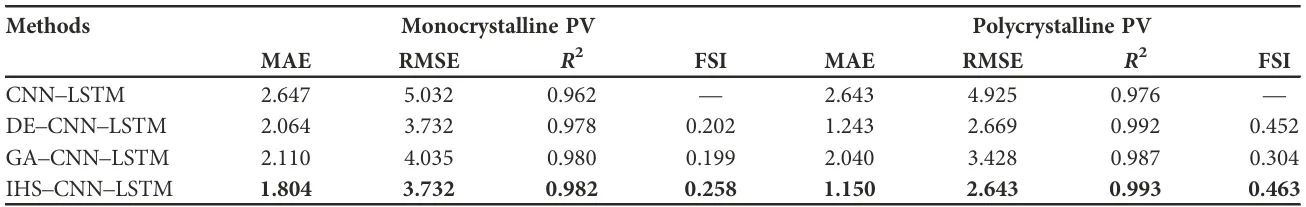

In [ ]:
# valid의 평가 지표 계산
from utils.test import metrics
best_path = f'results/best_CNN_LSTM.pth'
val_mae, val_rmse, val_mape, val_r2 = metrics(best_path, LSTM, valid_loader, y_scaler, device)
print(f"[Valid evaluation | CNN_LSTM] Valid MAE: {val_mae:.4f}, RMSE: {val_rmse:.4f}, MAPE: {val_mape:.4f}, R2: {val_r2:.4f}")